# HHBANK - 2 COUNTRY GITHUB VERSION 

In [1]:
# PACKAGES AND PATHS 
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
from sequence_jacobian import simple, solved, combine, create_model
from sequence_jacobian import grids, hetblocks

from pathlib import Path
import numpy as np


from pathlib import Path
import numpy as np
from sequence_jacobian import grids

try:
    BASE_DIR_D = Path(__file__).resolve().parent
except NameError:
    BASE_DIR_D = Path.cwd()


DATA_DIR_D = BASE_DIR_D / "Discretisation" / "Outputs"


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CALIBRATION
# ═══════════════════════════════════════════════════════════════════════
calibration_start = {

    # ── Preferences ──────────────────────────────────────────────────────
    #                              D               F
    'frisch_D':     1.0,    'frisch_F':     1.0,    # Frisch elasticity of labour supply
    'eis_D':        0.5,    'eis_F':        0.5,    # Elasticity of intertemporal substitution

    # ── Rates & Asset Prices ─────────────────────────────────────────────
    'rdep_D':       0.0065, 'rdep_F':       0.0065, # Real deposit rate (initial guess; endogenous in transition)
    'q_b_D':        0.85,   'q_b_F':        0.85,   # Bond price initial guess (endogenous; solved by bond_price_ss)
    'Q_D':          1.0,    'Q_F':          1.0,    # Tobin's q

    # ── Production ───────────────────────────────────────────────────────
    'alpha_D':      0.35,   'alpha_F':      0.35,   # Capital share
    'delta_D':      0.025, 'delta_F':      0.025,   # Quarterly depreciation rate
    'ksi_D':        0.5,    'ksi_F':        0.5,    # Capital adjustment cost curvature

    # ── Long-term bonds (Hatchondo-Martinez geometric-decay perpetuity) ──
    # Each bond unit pays delta_b per period; surviving fraction = (1-delta_b).
    # Modified duration ≈ (1-delta_b)/delta_b quarters.
    # D = Greece 2011 avg maturity ~7yr = 28Q → delta_b_D = 1/28 ≈ 0.036, dur ≈ 26Q
    # F = Germany 2011 avg maturity ~6.5yr = 26Q → delta_b_F = 1/26 ≈ 0.038, dur ≈ 24Q
    # Bond price is endogenous (bond_price_ss block); q_b above is starting guess only.
    'delta_b_D':   0.036,  'delta_b_F':   0.038,

    # ── Aggregate Targets (SS) ───────────────────────────────────────────
    'Y_D':          1.00,   'Y_F':          1.00,   # Output
    'Y_ss_D':       1.0,    'Y_ss_F':       1.0,    # SS output anchor (government_default debt-gap)
    'N_D':          1.00,   'N_F':          1.00,   # Labour
    'w_D':          0.65,   'w_F':          0.65,   # Real wage

    # ── Financial Intermediaries (Gertler-Karadi) ─────────────────────────
    'f_D':          0.03,   'f_F':          0.03,   # Exit probability
    'lambda_gk_D':  0.2,    'lambda_gk_F':  0.2,    # Divertability fraction (IC constraint & P1 Bellman)
    # Relative divertability Delta_i (vs capital = 1): Delta < 1 = better collateral.
    # Enters IC via (1 - Delta_i)·phi_i correction; Delta = 1 → single-lambda GK.
    # Replaces old lambda_K/BD/BF (those ÷lambda_B caused leverage oscillation).
    'Delta_bD_D':   0.2,    'Delta_bF_F':   0.2,    # Domestic bonds (preferred — better collateral)
    'Delta_bF_D':   0.4,    'Delta_bD_F':   0.4,    # Foreign bonds (penalised — weaker collateral)
    # lambda_BD/BF still used by divert_bond_foc_D/F for required spread scaling
    'lambda_BD_D':  0.06,   'lambda_BF_F':  0.06,   # Domestic bond risk-weight (FOC spread)
    'lambda_BF_D':  0.12,   'lambda_BD_F':  0.12,   # Foreign bond risk-weight (FOC spread)
    'psi_lambda_B_D': 0.0,  'psi_lambda_B_F': 0.0,  # State-dependence of bond divertability (0 = off)
    'n_inter_D':    0.75*4, 'n_inter_F':    0.75*4, # Bank net worth
    'theta_D':      4,      'theta_F':      4,      # Leverage ratio

    # ── Fiscal & Government Debt ─────────────────────────────────────────
    'B_supply_D':   6.414,  'B_supply_F':   8.4768,  # Total bond supply — overwritten by EBA cell below
    'b_gov_D':      6.414,  'b_gov_F':      8.4768,  # Government bonds outstanding (face value)
    'b_gov_ss_D':   6.414,  'b_gov_ss_F':   8.4768,  # SS debt anchor

    # ── Fiscal Rule (transfers) ──────────────────────────────────────────
    'tau_D':        0.181,  'tau_F':        0.181,  # Tax rate
    'lamb_D':       0.85,   'lamb_F':       0.85,   # Transfer-to-output ratio
    'lamb_ss_D':    0.85,   'lamb_ss_F':    0.85,   # SS transfer anchor
    # phi_lamb = 0.03 → annual Bohn coefficient = phi_lamb * 4 = 0.12
    # Literature: 0.10–0.15 for EA periphery (Staehr 2008). Was 0.4 → Bohn = 1.6, too aggressive.
    'phi_lamb_D':   0.03,   'phi_lamb_F':   0.03,   # Surplus response to debt gap (Bohn rule)

    # ── Sovereign Default ────────────────────────────────────────────────
    'shock_def_D':      0.000,  'shock_def_F':      0.0,    # Exogenous default shock
    'def_rate_D':       0.000,  'def_rate_F':       0.0,    # Default rate (SS = 0)
    'def_scale_D':      0.0,    'def_scale_F':      0.0,    # Endogenous default sensitivity
    'def_curvature_D':  0.5,    'def_curvature_F':  0.5,    # Power-function curvature
    'def_offset_D':     0.05,   'def_offset_F':     0.05,   # Linearisation offset
    'recovery_rate_D':  0.40,   'recovery_rate_F':  0.40,   # Recovery on defaulted debt
    'zeta_writeoff_D':  1.0,    'zeta_writeoff_F':  1.0,    # 1 = full write-off; 0 = coupon haircut
    'writeoff_enabled_D': 0.0,  'writeoff_enabled_F': 0.0,  # 0 = pure risk shock (no write-off); 1 = write-off regime

    # ── Intermediary Capital Adjustment Cost (Auclert 2019) ──────────────
    'chi0_D':           0.01,   'chi0_F':           0.01,   # Regularisation constant (prevents division by zero)
    'chi1_D':           0.5,    'chi1_F':           0.5,    # Cost scale
    'chi2_D':           2.0,    'chi2_F':           2.0,    # Cost curvature (2 = quadratic)

    # ── Macroprudential Bond Tax ──────────────────────────────────────────
    'T0_D':             0.000,  'T0_F':             0.000,  # Flat per-bond tax (breaks portfolio indeterminacy)
    'T1_D':             0.0,    'T1_F':             0.0,    # Sensitivity to default probability

    # ── Trade & Terms of Trade ───────────────────────────────────────────
    'omega':            0.85,   # Home bias in consumption
    'epsilon_trade':    1.5,    # Trade elasticity
    'p':                1.0,    # Terms of trade (SS = 1)

    # ── Cross-Border Bond Portfolio ──────────────────────────────────────
    'phi_bF_D_ss':  0.25,   'phi_bD_F_ss':  0.25,   # Initial portfolio shares (used to seed b_F_D/b_D_F)
    'psi_bF_D':     0.5,    'psi_bD_F':     0.5,    # Portfolio adjustment cost (level-based) — reduced for smaller cross-border positions

    # ── Wage Markups (calibrate vphi via labor_ss) ───────────────────────
    'mu_w_D':       1.0,    'mu_w_F':       1.0,    # Wage markup (SS; used by labor_ss to pin vphi)

    # ── SS Real Variables ─────────────────────────────────────────────────
    'mc_D':         1.0,    'mc_F':         1.0,    # Marginal cost (= 1 under flexible prices)

    # ── Idiosyncratic Income Process (Rouwenhorst grid) ──────────────────
    'rho_z_D':  0.90,    'rho_z_F':  0.97,           # AR(1) persistence
    'sigma_z_D': 0.8,   'sigma_z_F': 0.8,           # Innovation std dev
    'nZ_D':     7,     'nZ_F':     7,             # Income grid points
    'nDep_D':   500,    'nDep_F':   500,            # Deposit grid points
    'Depmax_D': 150,    'Depmax_F': 150,            # Max deposit (borrowing limit)
}

calibration_start_D = {k: v for k, v in calibration_start.items() if k.endswith('_D')}
calibration_start_F = {k: v for k, v in calibration_start.items() if k.endswith('_F')}

calibration_hh_D = {**calibration_start_D, 'beta_D': 0.9920094934, 'div_D': 0.19}
calibration_hh_F = {**calibration_start_F, 'beta_F': 0.9870643761, 'div_F': 0.21}


In [3]:
# ── Bond Holdings (initial SS guess; portfolio anchors overwritten post-solve) ──
_n_D, _n_F = calibration_start['n_inter_D'], calibration_start['n_inter_F']
_asset_D = calibration_start['theta_D'] * _n_D
_asset_F = calibration_start['theta_F'] * _n_F

# Corrected EBA sovereign bond shares by debtor country and bank asset base.
# EBA aggregate data (2011 end): Greek banking system ~€222bn TA, German ~€1,222bn TA.
# Corrected for unit mismatch (bond-to-equity vs bond-to-assets):
# D banks (Greece) hold Greek sovereign bonds and a small share of German sovereign bonds.
# F banks (Germany) hold German sovereign bonds and a small share of Greek sovereign bonds.
b_F_D = 0.0018 * _asset_D   # German sovereign bonds held by Greek banks (system aggregate, not GR030 alone)
b_D_F = 0.0065 * _asset_F   # Greek sovereign bonds held by German banks
b_D_D = 0.2447 * _asset_D   # Greek sovereign bonds held by Greek banks (corrected bond-to-asset ratio)
b_F_F = 0.2579 * _asset_F   # German sovereign bonds held by German banks (corrected bond-to-asset ratio)

_B_D = b_D_D + b_D_F
_B_F = b_F_F + b_F_D

calibration_start.update({
    'B_supply_D': _B_D,  'B_supply_F': _B_F,
    'b_gov_D': _B_D,     'b_gov_F': _B_F,
    'b_gov_ss_D': _B_D,  'b_gov_ss_F': _B_F,
    'b_F_D': b_F_D,      'b_D_F': b_D_F,
    'b_D_D': b_D_D,      'b_F_F': b_F_F,
    'b_F_D_anchor': b_F_D, 'b_D_F_anchor': b_D_F,   # initial guess; overwritten post-solve
    'psi_bD_D': 0.5,        'psi_bF_F': 0.5,
})


In [4]:
from equations_D import (hh_init_D, hh_D, make_grids_D, income_D, hh_extended_D)
from equations_F import (hh_init_F, hh_F, make_grids_F, income_F, hh_extended_F)

### EQUATIONS

#### STEADY STATE EQUATIONS

In [5]:
from equations_D import (
    smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, sdf_D, sdf_ss_D, government_ss_D, labor_ss_D,
    government_default_D, bond_price_ss_D, bond_return_D,
    ces_price_D, import_demand_D, deposit_return_D,
)

from equations_F import (
    smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, sdf_F, sdf_ss_F, government_ss_F, labor_ss_F,
    government_default_F, bond_price_ss_F, bond_return_F,
    ces_price_F, import_demand_F, deposit_return_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, portfolio_adj_cost, bond_yield,
    global_goods_mkt, external_account_D,
)


### SOLVING MODEL

#### STEADY STATE

In [6]:
import copy

ha = sj.create_model([
    sdf_ss_D, government_default_D, bond_price_ss_D, bond_return_D,
    sdf_ss_F, government_default_F, bond_price_ss_F, bond_return_F,
    hh_extended_D, smart_steady_D, market_clearing_D, steady_auxilliary_D,
    banker_div_D, government_ss_D, labor_ss_D,
    hh_extended_F, smart_steady_F, market_clearing_F, steady_auxilliary_F,
    banker_div_F, government_ss_F, labor_ss_F,
    ces_price_D, import_demand_D, ces_price_F, import_demand_F,
    deposit_return_D, deposit_return_F,
    bond_yield,
    trade_balance, external_account_D, global_goods_mkt,
], name='MU HA Model 2 Country')

unknowns_ss = {'beta_D': 0.9678948189, 'beta_F': 0.9654079110, 'p': 0.997170}
targets_ss  = ['deposit_mkt_D', 'deposit_mkt_F', 'ca_res_D']

ss = ha.solve_steady_state(calibration_start, unknowns_ss, targets_ss, solver='broyden_custom')

# ── Post-solve anchors ────────────────────────────────────────────────────────
anchors = {
    # Share-based values for bond portfolio FOCs (divert_bond_foc_D/F)
    'phi_bD_D_ss':           float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D']),
    'phi_bF_F_ss':           float(ss['q_b_F']) * float(ss['b_F_F']) / (float(ss['p']) * float(ss['n_inter_F'])),
    # Level anchors → portfolio_level_anchors block → b_F_D_ss, b_D_F_ss
    'b_F_D_anchor':          float(ss['b_F_D']),
    'b_D_F_anchor':          float(ss['b_D_F']),
    # Excess returns used by divert_bond_foc_D/F and divert_portfolio_adj
    'excess_return_bD_D_ss': float(ss['rb_actual_D']) - float(ss['rdep_D']) - calibration_start['T0_D'],
    'excess_return_bF_F_ss': float(ss['rb_actual_F']) - float(ss['rdep_F']) - calibration_start['T0_F'],
    'excess_return_F_D_ss':  float(ss['rb_actual_F']) - float(ss['rdep_D']) - calibration_start['T0_D'],
    'excess_return_D_F_ss':  float(ss['rb_actual_D']) - float(ss['rdep_F']) - calibration_start['T0_F'],
    'q_b_D':                 float(ss['q_b_D']),
    'q_b_F':                 float(ss['q_b_F']),
    'p':                     float(ss['p']),
    # SS consumption levels — denominators for welfare_agg_D/F normalisation
    'C_D_ss':                float(ss['C_D']),
    'C_F_ss':                float(ss['C_F']),
}
calibration_start.update(anchors)
for k, v in anchors.items():
    ss.toplevel[k] = v

ss.toplevel['b_F_D_ss'] = float(ss['b_F_D'])
ss.toplevel['b_D_F_ss'] = float(ss['b_D_F'])


ss.toplevel['Rgross_D'] = float(1 + ss['rdep_D'])
ss.toplevel['Rgross_F'] = float(1 + ss['rdep_F'])

_fr_D = float(ss['frisch_D']); _fr_F = float(ss['frisch_F'])
ss.toplevel['X_D'] = float(ss['C_D']) - float(ss['vphi_D']) * float(ss['N_D']) ** (1 + 1/_fr_D) / (1 + 1/_fr_D)
ss.toplevel['X_F'] = float(ss['C_F']) - float(ss['vphi_F']) * float(ss['N_F']) ** (1 + 1/_fr_F) / (1 + 1/_fr_F)
ss.toplevel['U_D'] = ss.toplevel['X_D'] / float(ss['C_D'])
ss.toplevel['U_F'] = ss.toplevel['X_F'] / float(ss['C_F'])

for k, v in {
    'tau_mp_D':        0.0,  'tau_mp_F':        0.0,
    'Phi_D':           0.0,  'Phi_F':           0.0,
    'T_D':             0.0,  'T_F':             0.0,
    'b_F_D_res':       0.0,  'b_D_F_res':       0.0,
    'rb_D_res':        0.0,  'rb_F_res':        0.0,
    'labor_mkt_res_D': 0.0,  'labor_mkt_res_F': 0.0,
    'w_res_D':         0.0,  'w_res_F':         0.0,
}.items():
    ss.toplevel[k] = v

# ── SS Bellman values for three ν's (consumed by ha_full as inner unknowns) ──
for k in ('nu_K_D', 'nu_bD_D', 'nu_bF_D', 'eta_D',
          'nu_K_F', 'nu_bF_F', 'nu_bD_F', 'eta_F'):
    if k not in ss.toplevel:
        ss.toplevel[k] = 0.0

cali_D = cali_F = ss
ss_final = copy.deepcopy(ss)

print(f"beta_D={ss['beta_D']:.10f}  beta_F={ss['beta_F']:.10f}  p={ss['p']:.6f}")
print(f"lambda_gk_D={ss['lambda_gk_D']:.6f}  lambda_gk_F={ss['lambda_gk_F']:.6f}")
print(f"rb_D={ss['rb_D']:.6f}  rb_F={ss['rb_F']:.6f}  rdep_D={ss['rdep_D']:.6f}  rdep_F={ss['rdep_F']:.6f}")
print(f"q_b_D={anchors['q_b_D']:.6f}  q_b_F={anchors['q_b_F']:.6f}")
print(f"vphi_D={float(ss['vphi_D']):.6f}  vphi_F={float(ss['vphi_F']):.6f}")
print(f"X_D={ss.toplevel['X_D']:.6f}  X_F={ss.toplevel['X_F']:.6f}")
print(f"C_D_ss={anchors['C_D_ss']:.6f}  C_F_ss={anchors['C_F_ss']:.6f}  (welfare normalisers)")

beta_D=0.9705898772  beta_F=0.9686052454  p=1.000301
lambda_gk_D=0.256806  lambda_gk_F=0.263342
rb_D=0.606026  rb_F=0.648247  rdep_D=0.006500  rdep_F=0.006500
q_b_D=0.622655  q_b_F=0.606705
vphi_D=0.649971  vphi_F=0.650029
X_D=0.377519  X_F=0.384139
C_D_ss=0.702505  C_F_ss=0.709153  (welfare normalisers)


In [7]:
# ── Post-solve overrides ──────────────────────────────────────────────────────
_overrides = {
    'psi_lambda_B_D': 1.0,   # divertability premium loading
    'psi_lambda_B_F': 1.0,
    'chi1_D':         0.0,   # intermediary capital adj cost inert at SS -> drop
    'chi1_F':         0.0,
    'psi_bD_D':       0.1,
    'psi_bF_F':       0.1,
    'psi_bF_D':       0.1,
    'psi_bD_F':       0.1,
}
for _d in (ss.toplevel, ss_final.toplevel):
    for _k, _v in _overrides.items():
        _d[_k] = _v
calibration_start.update(_overrides)
print("Overrides applied.")

Overrides applied.


In [8]:
print("SS goods residuals:")
print("goods_mkt_D     =", ss['goods_mkt_D'])
print("goods_mkt_F     =", ss['goods_mkt_F'])
print("global_goods_res=", ss['global_goods_res'])
print("ca_res_D        =", ss['ca_res_D'])

SS goods residuals:
goods_mkt_D     = -3.855602362379251e-08
goods_mkt_F     = -7.497389500898954e-09
global_goods_res= -4.6055670856546384e-08
ca_res_D        = 1.457167719820518e-16


In [9]:
# ── SS residual diagnostic ─────────────────────────────────────────────────────
def _get(k):
    return float(ss[k])

diag = {}

# ── Multi-asset GK IC ──────────────────────────────────────────────────────────
for c in ['D', 'F']:
    pdiv    = _get('p') if c == 'F' else 1.0
    eta_c   = _get(f'eta_{c}')
    lam     = _get(f'lambda_gk_{c}')
    theta_c = _get(f'theta_{c}')
    Q_c     = _get(f'Q_{c}')
    K_c     = _get(f'K_{c}')
    n_c     = _get(f'n_inter_{c}')
    kappa_c = Q_c * K_c / n_c
    if c == 'D':
        nu_K, nu_bD, nu_bF = _get('nu_K_D'), _get('nu_bD_D'), _get('nu_bF_D')
        q_h, q_x = _get('q_b_D'), _get('q_b_F')
        b_h, b_x = _get('b_D_D'), _get('b_F_D')
    else:
        nu_K, nu_bD, nu_bF = _get('nu_K_F'), _get('nu_bD_F'), _get('nu_bF_F')
        q_h, q_x = _get('q_b_F'), _get('q_b_D')
        b_h, b_x = _get('b_F_F'), _get('b_D_F')
    phi_h = q_h * b_h / (pdiv * n_c)
    phi_x = q_x * b_x / (pdiv * n_c)
    LHS = (nu_K * kappa_c
           + (nu_bD if c == 'D' else nu_bF) * phi_h
           + (nu_bF if c == 'D' else nu_bD) * phi_x
           + eta_c)
    diag[f'IC_{c}: LHS − λ·θ'] = LHS - lam * theta_c

# ── Bellman P1 residuals ───────────────────────────────────────────────────────
for c in ['D', 'F']:
    f_c    = _get(f'f_{c}')
    lam    = _get(f'lambda_gk_{c}')
    th     = _get(f'theta_{c}')
    beta_c = _get(f'beta_{c}')
    rk_c   = _get(f'rk_{c}')
    rdep_c = _get(f'rdep_{c}')
    eta_c  = _get(f'eta_{c}')
    Omega_p1 = f_c + (1 - f_c) * lam * th
    rb_h = _get('rb_actual_D' if c == 'D' else 'rb_actual_F')
    rb_x = _get('rb_actual_F' if c == 'D' else 'rb_actual_D')
    nu_K_c  = _get(f'nu_K_{c}')
    nu_bh_c = _get('nu_bD_D' if c == 'D' else 'nu_bF_F')
    nu_bx_c = _get('nu_bF_D' if c == 'D' else 'nu_bD_F')
    diag[f'P1_{c}: nu_K_res']  = nu_K_c  - beta_c * Omega_p1 * (rk_c - rdep_c)
    diag[f'P1_{c}: nu_bh_res'] = nu_bh_c - beta_c * Omega_p1 * (rb_h - rdep_c)
    diag[f'P1_{c}: nu_bx_res'] = nu_bx_c - beta_c * Omega_p1 * (rb_x - rdep_c)
    diag[f'P1_{c}: eta_res']   = eta_c   - beta_c * Omega_p1 * (1 + rdep_c)

# ── GHH labor market FOC: w/P_CES = vphi·N^(1/frisch) (UCE cancels out) ──────
for c in ['D', 'F']:
    w_c    = _get(f'w_{c}')
    P_c    = _get(f'P_CES_{c}')
    N_c    = _get(f'N_{c}')
    vphi_c = _get(f'vphi_{c}')
    fr_c   = _get(f'frisch_{c}')
    diag[f'labor_mkt_{c}: w/P − vphi·N^(1/fr)'] = w_c / P_c - vphi_c * N_c ** (1 / fr_c)

# ── Cross-border portfolio FOC (level-based, matches portfolio_adj_cost) ───────
for (c, cross, b_key, b_ss_key, psi_key, er_key) in [
    ('D', 'F', 'b_F_D', 'b_F_D_ss', 'psi_bF_D', 'excess_return_F_D_ss'),
    ('F', 'D', 'b_D_F', 'b_D_F_ss', 'psi_bD_F', 'excess_return_D_F_ss'),
]:
    diag[f'portfolio_adj_b{cross}_{c}'] = (
        (_get(f'rb_actual_{cross}') - _get(f'rdep_{c}'))
        - _get(er_key)
        - calibration_start[psi_key] * (_get(b_key) - _get(b_ss_key))
        - _get(f'tau_mp_{c}')
    )

# ── Domestic bond FOC (share-based, matches domestic_bond_foc_D/F) ────────────
for c in ['D', 'F']:
    pdiv       = _get('p') if c == 'F' else 1.0
    phi_dom    = _get(f'q_b_{c}') * _get(f'b_{c}_{c}') / (pdiv * _get(f'n_inter_{c}'))
    phi_dom_ss = _get(f'phi_b{c}_{c}_ss')
    psi_dom    = _get(f'psi_b{c}_{c}')
    er_dom     = _get(f'excess_return_b{c}_{c}_ss')
    diag[f'dom_bond_foc_{c}'] = (
        (_get(f'rb_actual_{c}') - _get(f'rdep_{c}'))
        - er_dom
        - psi_dom * (phi_dom - phi_dom_ss)
        - calibration_start[f'T0_{c}']
    )

diag['ca_res_D'] = _get('ca_res_D')

TOL = 1e-8
print(f"\n{'Block residual':<52} {'Value':>14}  Status")
print("-" * 82)
FLAGGED = []
for name, val in diag.items():
    ok = abs(val) <= TOL
    if not ok:
        FLAGGED.append(name)
    print(f"  {name:<50} {val:>14.6e}  {'OK' if ok else '*** FAIL'}")
print("-" * 82)
print("\nAll residuals < 1e-8  ✓" if not FLAGGED else f"\nFLAGGED: {FLAGGED}")


Block residual                                                Value  Status
----------------------------------------------------------------------------------
  IC_D: LHS − λ·θ                                     -2.220446e-16  OK
  IC_F: LHS − λ·θ                                     -2.220446e-16  OK
  P1_D: nu_K_res                                       0.000000e+00  OK
  P1_D: nu_bh_res                                      0.000000e+00  OK
  P1_D: nu_bx_res                                      0.000000e+00  OK
  P1_D: eta_res                                        0.000000e+00  OK
  P1_F: nu_K_res                                       0.000000e+00  OK
  P1_F: nu_bh_res                                      0.000000e+00  OK
  P1_F: nu_bx_res                                      0.000000e+00  OK
  P1_F: eta_res                                        0.000000e+00  OK
  labor_mkt_D: w/P − vphi·N^(1/fr)                     0.000000e+00  OK
  labor_mkt_F: w/P − vphi·N^(1/fr)              

#### OFF STEADY-STATE EQUATIONS

In [10]:
from equations_D import (
    capital_adj_D, labor_D,
    labor_market_D, labor_demand_D,
    intermediation_IC_D, bank_return_D, intermediation_P1_D,
    k_balance_sheet_D,
    cap_adj_cost_inter_D, macro_pru_tax_D,
    intermediation_P2_D, banker_div_res_D,
    intermediation_P3_D, government_default_D,
    divert_bond_foc_D,
    tax_rule_D, capital_producer_profit_D, budget_residual_D,
    ces_price_D, import_demand_D, deposit_return_D,
    bond_return_D, sdf_D, ghh_composite_D,
    welfare_agg_D,
)

from equations_F import (
    capital_adj_F, labor_F,
    labor_market_F, labor_demand_F,
    intermediation_IC_F, bank_return_F, intermediation_P1_F,
    k_balance_sheet_F,
    cap_adj_cost_inter_F, macro_pru_tax_F,
    intermediation_P2_F, banker_div_res_F,
    intermediation_P3_F, government_default_F,
    divert_bond_foc_F,
    tax_rule_F, capital_producer_profit_F, budget_residual_F,
    ces_price_F, import_demand_F, deposit_return_F,
    bond_return_F, sdf_F, ghh_composite_F,
    welfare_agg_F,
)

from equations_global import (
    trade_balance, domestic_bond_clearing,
    portfolio_level_anchors, divert_portfolio_adj, bond_yield,
    global_goods_mkt, external_account_D,
)

#### FULL MODEL

In [11]:
import sys
sys.setrecursionlimit(5000)   # SSJ topological sort uses recursion on deep block graphs

financial_solved_D = combine([
    intermediation_P1_D, intermediation_IC_D,
]).solved(
    unknowns={'nu_K_D':  float(cali_D['nu_K_D']),
              'nu_bD_D': float(cali_D['nu_bD_D']),
              'nu_bF_D': float(cali_D['nu_bF_D']),
              'eta_D':   float(cali_D['eta_D']),
              'theta_D': float(cali_D['theta_D'])},
    targets=['nu_K_res_D', 'nu_bD_res_D', 'nu_bF_res_D', 'eta_res_D', 'ic_res_D'],
    solver='broyden_custom'
)

financial_solved_F = combine([
    intermediation_P1_F, intermediation_IC_F,
]).solved(
    unknowns={'nu_K_F':  float(cali_F['nu_K_F']),
              'nu_bF_F': float(cali_F['nu_bF_F']),
              'nu_bD_F': float(cali_F['nu_bD_F']),
              'eta_F':   float(cali_F['eta_F']),
              'theta_F': float(cali_F['theta_F'])},
    targets=['nu_K_res_F', 'nu_bF_res_F', 'nu_bD_res_F', 'eta_res_F', 'ic_res_F'],
    solver='broyden_custom'
)

ha_full = sj.create_model([
    # ── Country D ──────────────────────────────────────────────────────────────
    deposit_return_D,           # Rgross_D = (1+rdep_D)*P_CES_D(-1)/P_CES_D
    hh_extended_D,
    ghh_composite_D,            # X_D = C_D - v(N_D); needed by sdf_D
    sdf_D,
    government_default_D,       # → def_rate_D
    financial_solved_D,         # 4 ν Bellmans + IC pin θ (inner solve)
    bond_return_D,
    bank_return_D,
    cap_adj_cost_inter_D,
    macro_pru_tax_D,
    intermediation_P2_D,
    intermediation_P3_D,
    k_balance_sheet_D,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_D,
    tax_rule_D,
    capital_producer_profit_D,
    budget_residual_D,
    labor_D,
    labor_market_D,             # GHH FOC: w/P_CES = vphi*N^(1/frisch)
    labor_demand_D,             # firm FOC: w = (1-α)*Y/N  → w_res_D
    banker_div_res_D,
    market_clearing_D,
    welfare_agg_D,              # U_D = X_D / C_D_ss

    # ── Country F ──────────────────────────────────────────────────────────────
    deposit_return_F,           # Rgross_F = (1+rdep_F)*P_CES_F(-1)/P_CES_F
    hh_extended_F,
    ghh_composite_F,            # X_F = C_F - v(N_F); needed by sdf_F
    sdf_F,
    government_default_F,       # → def_rate_F
    financial_solved_F,         # 4 ν Bellmans + IC pin θ (inner solve)
    bond_return_F,
    bank_return_F,
    cap_adj_cost_inter_F,
    macro_pru_tax_F,
    intermediation_P2_F,
    intermediation_P3_F,
    k_balance_sheet_F,          # Q*K = theta*n_inter  (GK IC)
    capital_adj_F,
    tax_rule_F,
    capital_producer_profit_F,
    budget_residual_F,
    labor_F,
    labor_market_F,             # GHH FOC: w/P_CES = vphi*N^(1/frisch)
    labor_demand_F,             # firm FOC: w = (1-α)*Y/N  → w_res_F
    banker_div_res_F,
    market_clearing_F,
    welfare_agg_F,              # U_F = X_F / C_F_ss

    # ── Global ─────────────────────────────────────────────────────────────────
    ces_price_D, import_demand_D,
    ces_price_F, import_demand_F,
    trade_balance,
    external_account_D,
    domestic_bond_clearing,
    bond_yield,
    portfolio_level_anchors,
    divert_portfolio_adj,       # replaces portfolio_adj_cost
    divert_bond_foc_D,          # replaces domestic_bond_foc_D
    divert_bond_foc_F,          # replaces domestic_bond_foc_F
    global_goods_mkt,
], name="Full 2-Country MU HANK — GHH Preferences, Flex Price & Wage, No CB")

# ── 23×23 system ──────────────────────────────────────────────────────────────
unknowns_tp = [
    'K_D', 'n_inter_D', 'div_D', 'I_D', 'Q_D', 'b_gov_D', 'N_D', 'b_F_D', 'w_D', 'rdep_D',
    'K_F', 'n_inter_F', 'div_F', 'I_F', 'Q_F', 'b_gov_F', 'N_F', 'b_D_F', 'w_F', 'rdep_F',
    'p', 'q_b_D', 'q_b_F',
]
targets_tp = [
    # D country (10 targets)
    'deposit_mkt_D', 'K_res_D', 'n_inter_val_D', 'div_res_D',
    'capital_res_D', 'q_res_D', 'b_gov_res_D', 'b_F_D_res',
    'labor_mkt_res_D', 'w_res_D',

    # F country (10 targets)
    'deposit_mkt_F', 'K_res_F', 'n_inter_val_F', 'div_res_F',
    'capital_res_F', 'q_res_F', 'b_gov_res_F', 'b_D_F_res',
    'labor_mkt_res_F', 'w_res_F',

    # Global (3 targets)
    'goods_mkt_D',
    'rb_D_res', 'rb_F_res',
]
T = 500
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F']

In [12]:
exogenous = ['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F']

print(f"Precomputing full GE Jacobian G with all {len(exogenous)} shocks (T={T})...")
G = ha_full.solve_jacobian(ss_final, unknowns=unknowns_tp, targets=targets_tp, inputs=exogenous,T=T)
print("G computed successfully. Now IRFs are just fast matrix multiplies.")


# TFP Shock
rho_Z_D = 0.8
dZ_D    = 0.01 * rho_Z_D ** np.arange(T)

# Default Shock
rho_def_D    = 0.8
dShock_def_D = 0.01 * rho_def_D ** np.arange(T)



# === IRF to TFP shock in D only ===
shock_Z_D = {
    'Z_D': dZ_D,
    'Z_F': np.zeros(T),
    'shock_def_D': np.zeros(T),
    'shock_def_F': np.zeros(T)
}
irfs_Z_D = G @ shock_Z_D

# === IRF to default shock in D only ===
shock_def_D = {
    'Z_D': np.zeros(T),
    'Z_F': np.zeros(T),
    'shock_def_D': dShock_def_D,
    'shock_def_F': np.zeros(T)
}
irfs_def_D = G @ shock_def_D

Precomputing full GE Jacobian G with all 4 shocks (T=500)...


G computed successfully. Now IRFs are just fast matrix multiplies.


### IMPULSE RESPONSE FUNCTIONS

In [13]:
BLUE    = '#002147'
RED   = '#8C1515'
BLUE_MUTED     = '#4a6f8a'  
RED_MUTED      = '#c0624a'

_COLORS     = [BLUE, RED, BLUE_MUTED, RED_MUTED]
_LINESTYLES = ['-', '--', '-.', ':']
_MARKERS    = ['', '', '', 'o']

def show_irfs(irfs_list, variables, labels=None,
              ylabel='Deviation from SS (pp)', T_plot=25, figsize=(18, 5)):

    labels = labels or [''] * len(irfs_list)
    n_var  = len(variables)
    fig, axes = plt.subplots(1, n_var, figsize=figsize, sharey=False)
    if n_var == 1:
        axes = [axes]

    for i, (ax, var) in enumerate(zip(axes, variables)):
        for j, (irf, label) in enumerate(zip(irfs_list, labels)):
            data = irf[var][:T_plot] if var in irf else np.zeros(T_plot)
            mkr  = _MARKERS[j % len(_MARKERS)]
            ax.plot(data,
                    color     = _COLORS[j % len(_COLORS)],
                    linestyle = _LINESTYLES[j % len(_LINESTYLES)],
                    linewidth = 1.8,
                    marker    = mkr,
                    markersize= 4,
                    markevery = 4,
                    label     = label)

        ax.axhline(0, color='#888888', linewidth=0.8, linestyle=':')
        ax.set_title(var, fontsize=10, pad=6)
        ax.set_xlabel('Quarter', fontsize=9)
        if i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=8)
        if any(l for l in labels):
            ax.legend(fontsize=8, frameon=False)

    fig.tight_layout()
    plt.show()


In [14]:
print("=== Default shock diagnostics ===")
print(f"def_rate_D[0]:    {irfs_def_D['def_rate_D'][0]*100:+.4f}%")
print(f"q_b_D[0]:         {irfs_def_D['q_b_D'][0]*100:+.4f}%  <- how much does price fall?")
print(f"rb_actual_D[0]:   {irfs_def_D['rb_actual_D'][0]*100:+.4f}%  <- realized return falls")
print(f"rb_actual_D[1]:   {irfs_def_D['rb_actual_D'][1]*100:+.4f}%  <- future return RISES?")
print(f"nu_bD_D[0]:       {irfs_def_D['nu_bD_D'][0]*100:+.4f}%  <- shadow value of bonds")
print(f"theta_D[0]:       {irfs_def_D['theta_D'][0]*100:+.4f}%  <- leverage RISES = perverse IC")
print(f"n_inter_D[0]:     {irfs_def_D['n_inter_D'][0]*100:+.4f}%  <- net worth falls?")
print(f"rn_D[0]:          {irfs_def_D['rn_D'][0]*100:+.4f}%  <- portfolio return")
phi_bD_ss = float(ss['q_b_D']) * float(ss['b_D_D']) / float(ss['n_inter_D'])
phi_bD_0  = (float(ss['q_b_D']) + irfs_def_D['q_b_D'][0]) * float(ss['b_D_D']) / float(ss['n_inter_D'])
print(f"phi_bD_D[0] approx: {phi_bD_0:.4f} vs SS {phi_bD_ss:.4f}")


=== Default shock diagnostics ===
def_rate_D[0]:    +1.0000%
q_b_D[0]:         -0.6168%  <- how much does price fall?
rb_actual_D[0]:   -0.9410%  <- realized return falls
rb_actual_D[1]:   +0.2805%  <- future return RISES?
nu_bD_D[0]:       +0.3442%  <- shadow value of bonds
theta_D[0]:       +4.4705%  <- leverage RISES = perverse IC
n_inter_D[0]:     -3.9934%  <- net worth falls?
rn_D[0]:          -1.3655%  <- portfolio return
phi_bD_D[0] approx: 0.6034 vs SS 0.6095


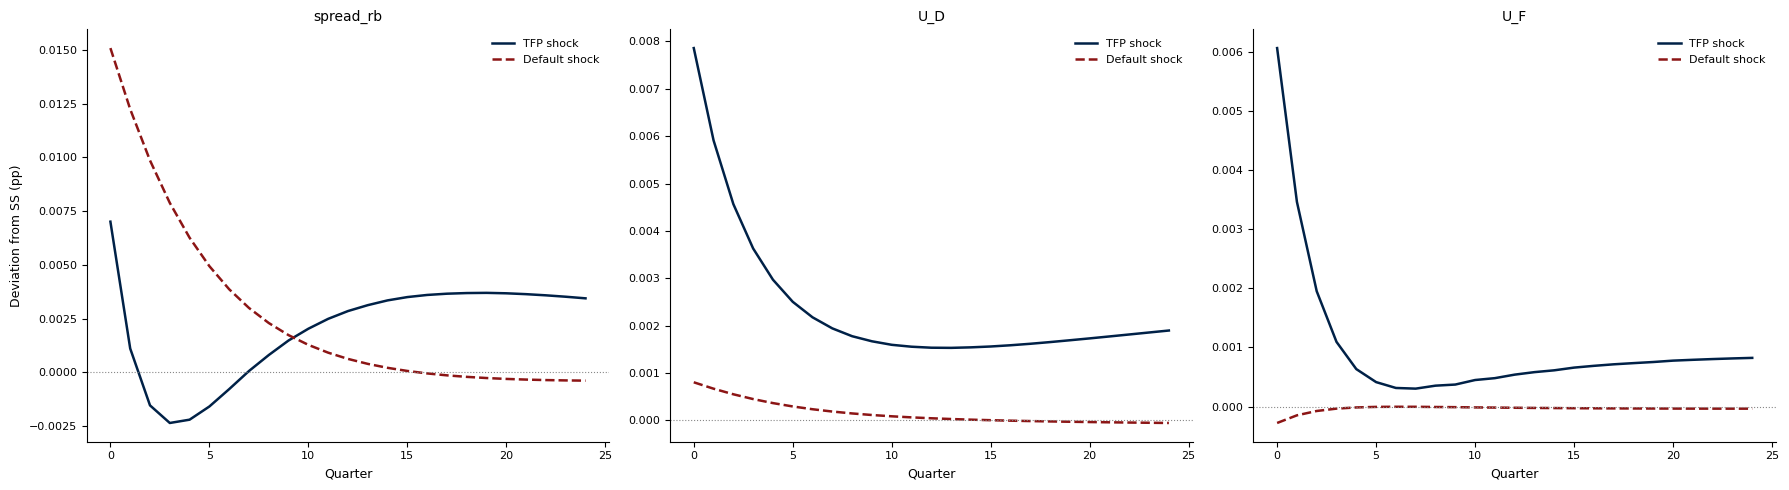

In [15]:
# Overview: output, consumption, real wage, bank net worth, bond rate
show_irfs([irfs_Z_D, irfs_def_D], ['spread_rb','U_D',"U_F"],['TFP shock', 'Default shock']) 

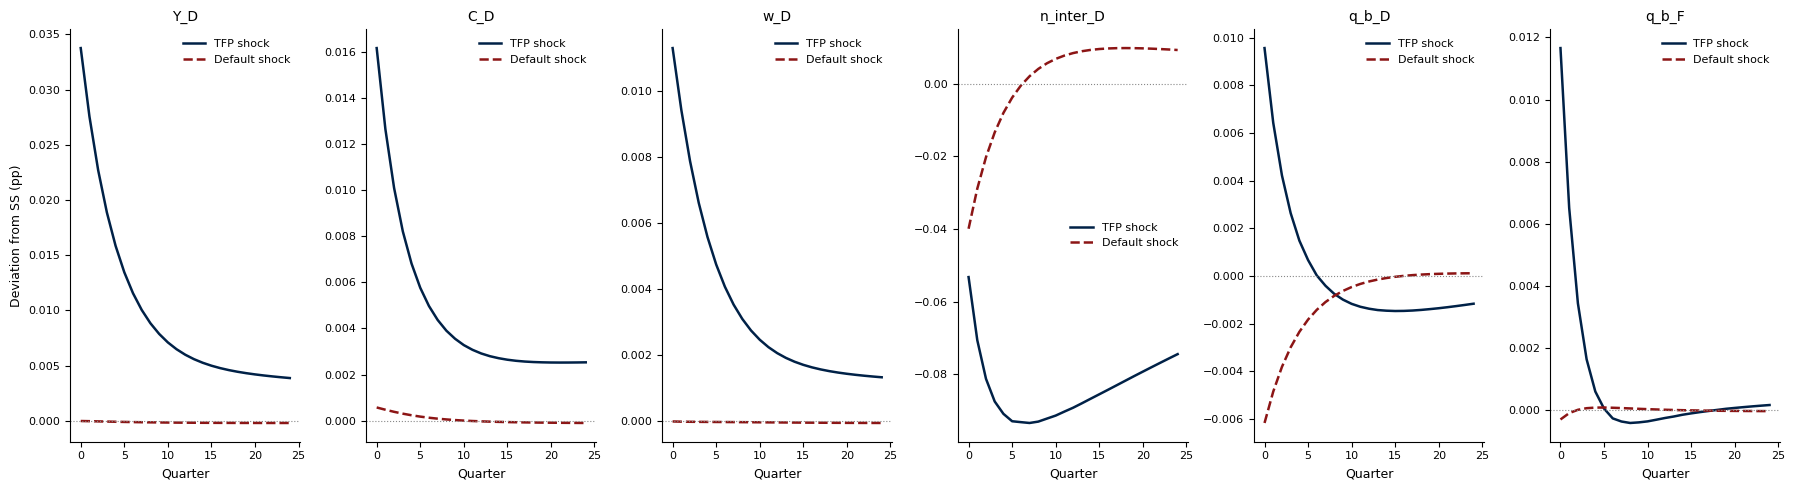

In [16]:
# Overview: output, consumption, real wage, bank net worth, bond rate
show_irfs([irfs_Z_D, irfs_def_D], 
          ['Y_D', 'C_D', 'w_D', 'n_inter_D', 'q_b_D', 'q_b_F'],
          ['TFP shock', 'Default shock']) 

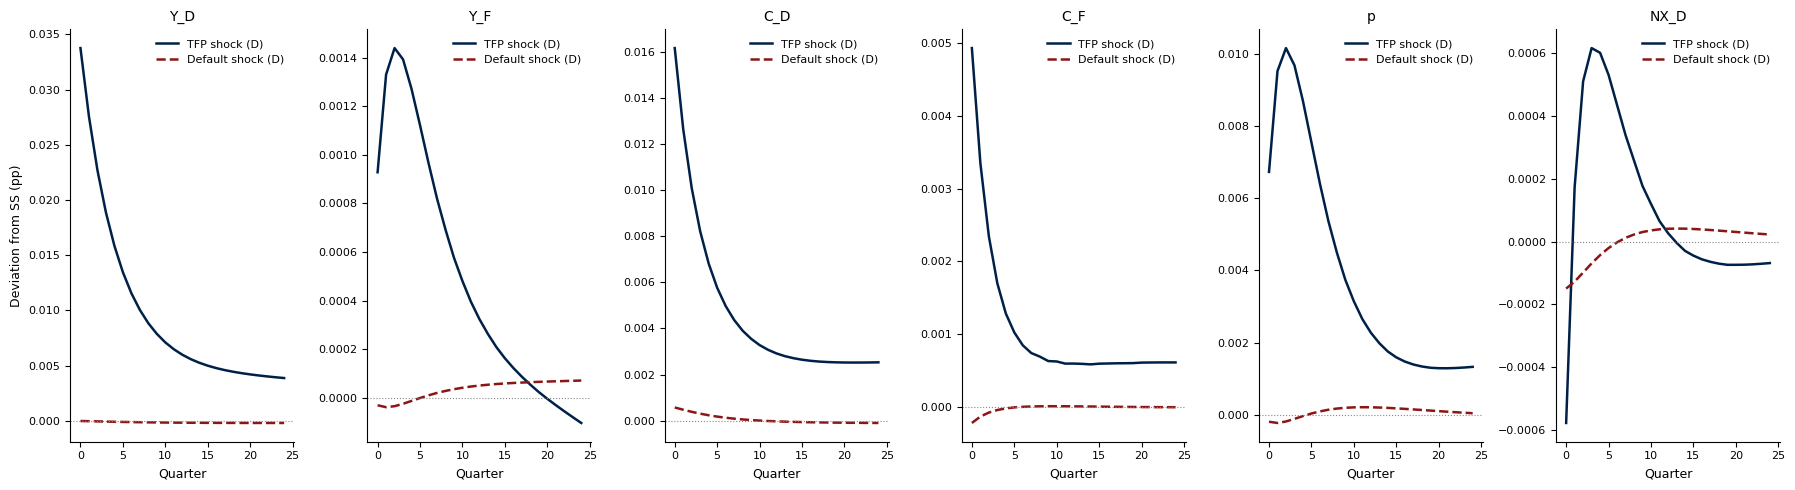

In [17]:
# ── 1. Output, Consumption & Trade ────────────────────────────────────────
# With flexible prices, inflation is zero; terms of trade p and NX adjust to
# clear goods markets across countries.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['Y_D', 'Y_F', 'C_D', 'C_F', 'p', 'NX_D'])

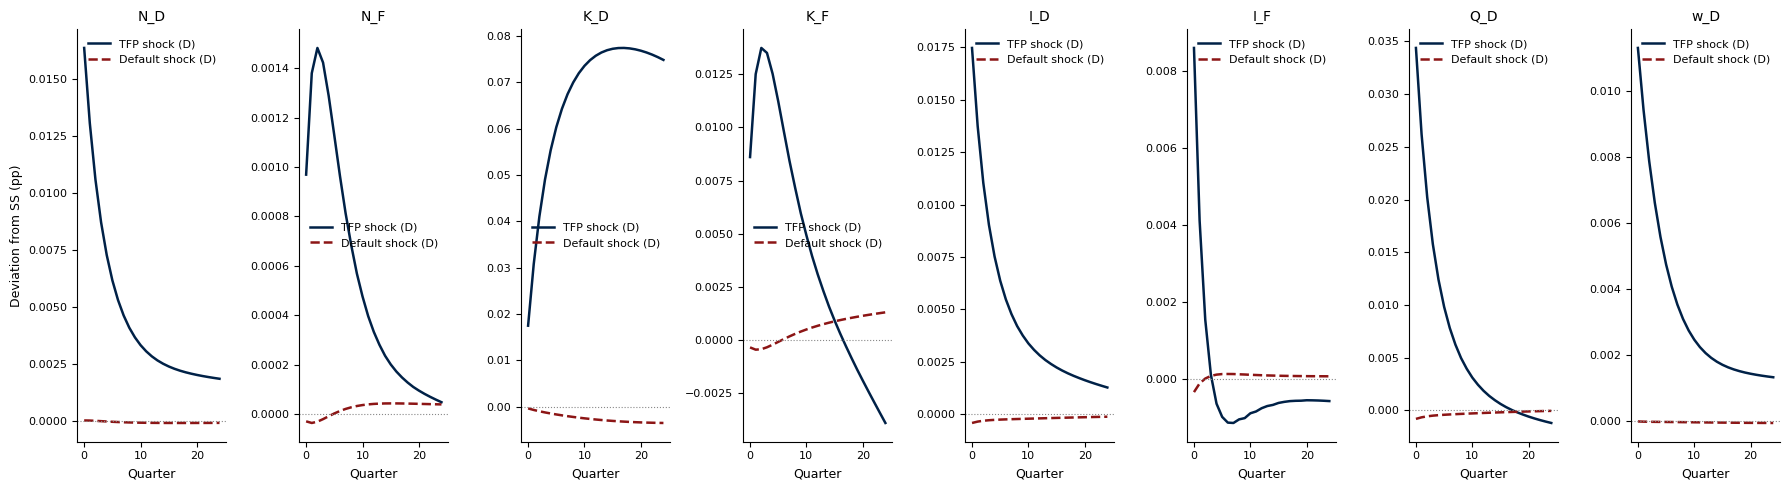

In [18]:
# ── 2. Labour, Capital & TFP ──────────────────────────────────────────────
# Suggestion: add Q (Tobin's q) and rk — these reveal whether output
# rigidity is coming from the investment or the labour margin.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['N_D', 'N_F', 'K_D', 'K_F', 'I_D', 'I_F', 'Q_D', 'w_D'])


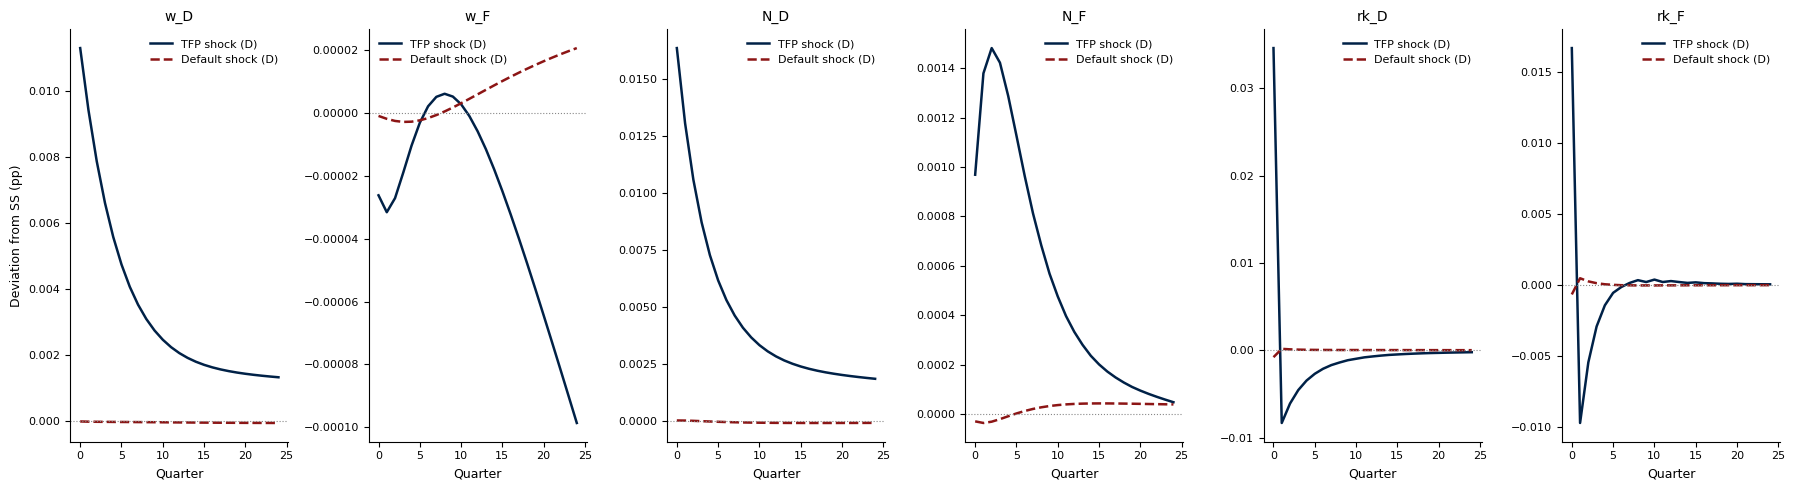

In [19]:
# ── 3. Factor Prices ──────────────────────────────────────────────────────────
# Under flexible prices mc = 1 always; the interesting margins are factor prices.
# rk = rental rate of capital; w = real wage. Both move with TFP and default shocks.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['w_D', 'w_F', 'N_D', 'N_F', 'rk_D', 'rk_F'])

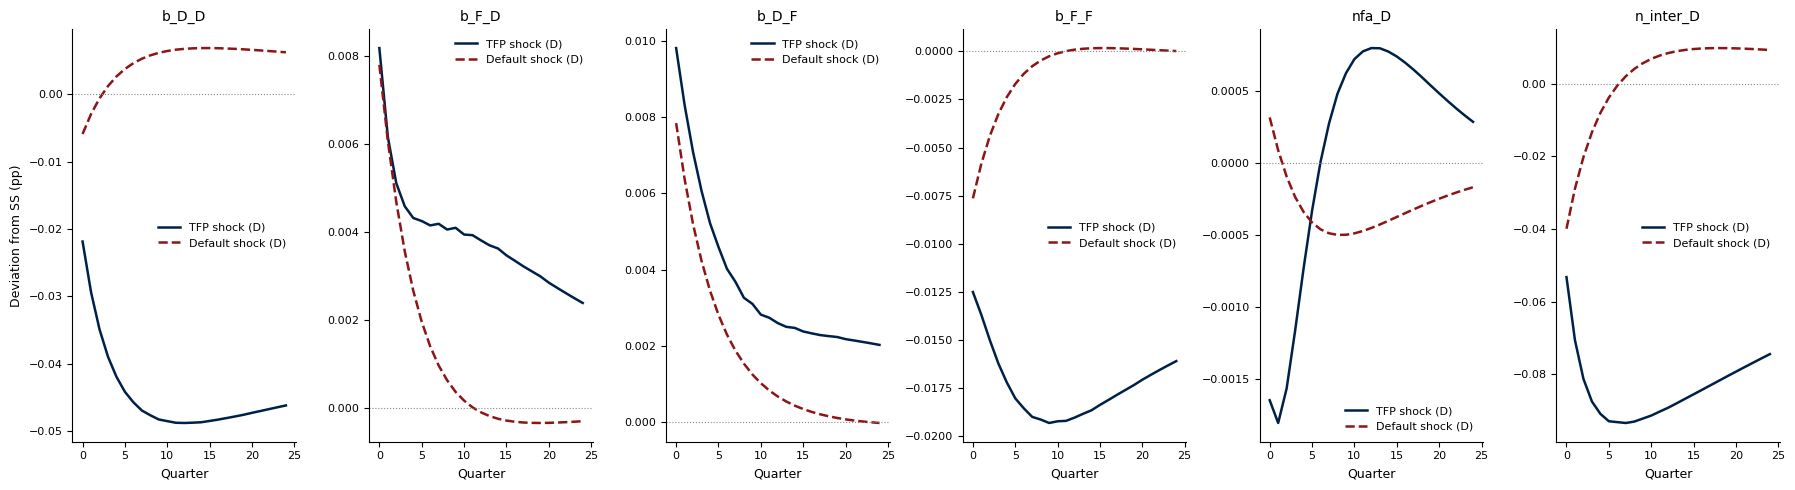

In [20]:
# ── 4. Bond Holdings & External Position ──────────────────────────────────────
# nfa_D = q_b_F·b_F_D − q_b_D·b_D_F: D's net foreign asset position (in D-goods).
# n_inter_D: D bank net worth — shows financial amplification of sovereign shocks.
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_D_D', 'b_F_D', 'b_D_F', 'b_F_F', 'nfa_D', 'n_inter_D'])

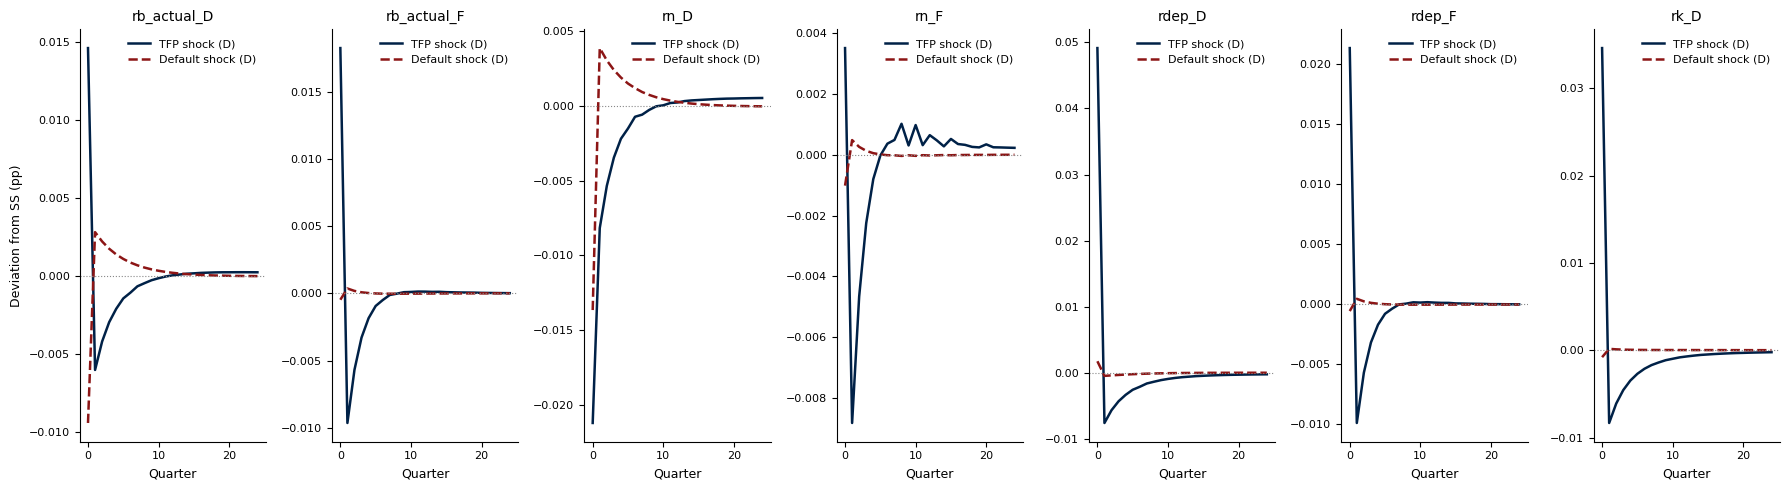

In [21]:
# ── 5. Rates & Returns ────────────────────────────────────────────────────────
# rdep_D/F are now endogenous (pinned by deposit market clearing in the 23×23 system).
# rk_D: return on physical capital. rn_D: bank portfolio return (mix of rk and rb).
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['rb_actual_D', 'rb_actual_F', 'rn_D', 'rn_F', 'rdep_D', 'rdep_F', 'rk_D'])

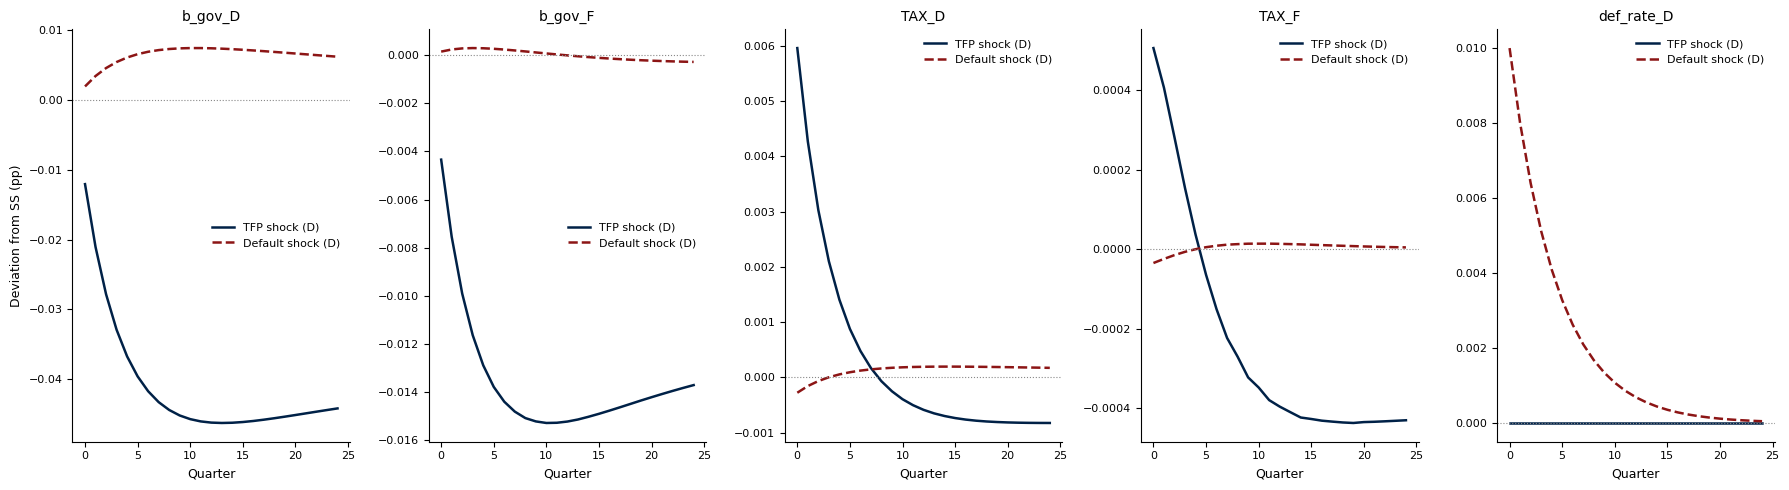

In [22]:
# ── 6. Fiscal ─────────────────────────────────────────────────────────────
show_irfs([irfs_Z_D, irfs_def_D], labels=['TFP shock (D)', 'Default shock (D)'],
          variables=['b_gov_D', 'b_gov_F', 'TAX_D', 'TAX_F', 'def_rate_D'])


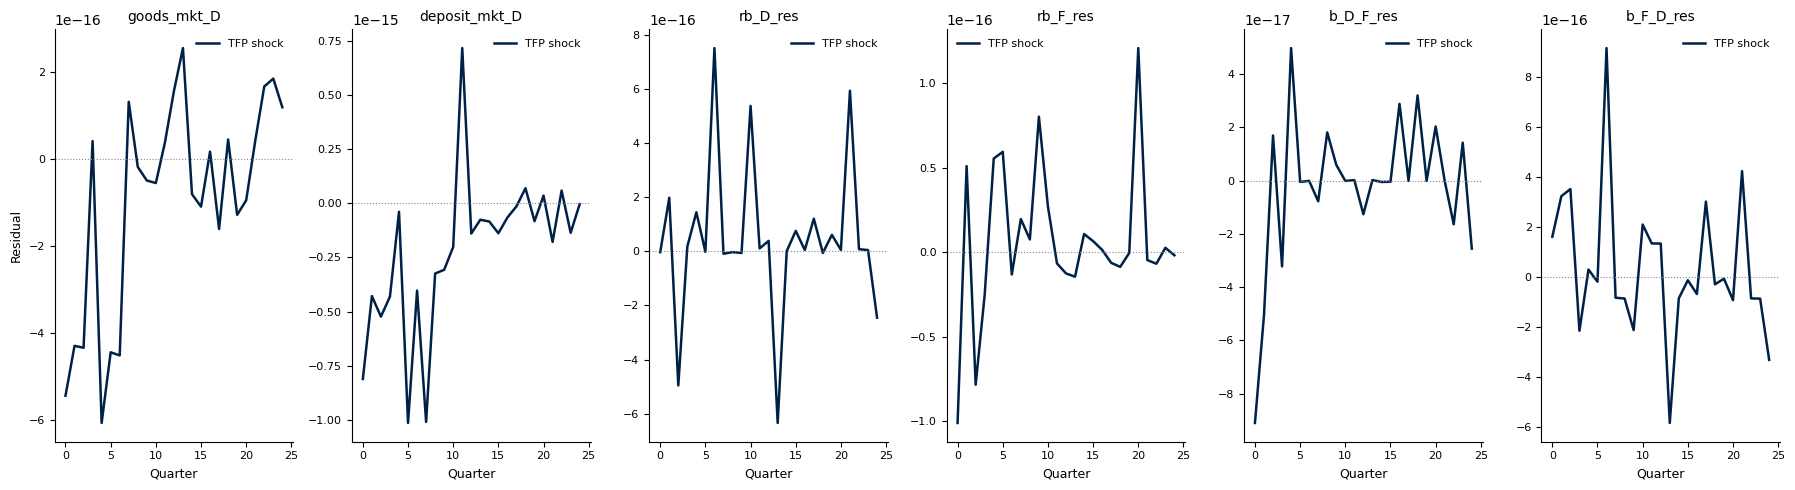

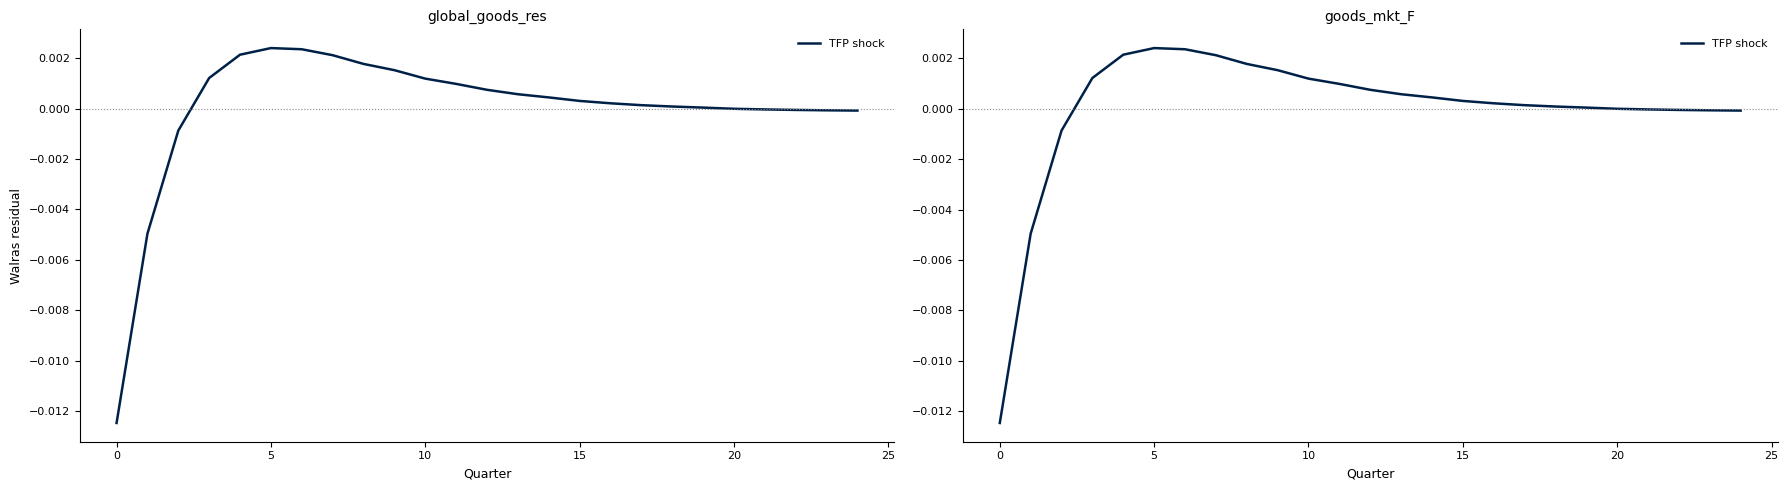

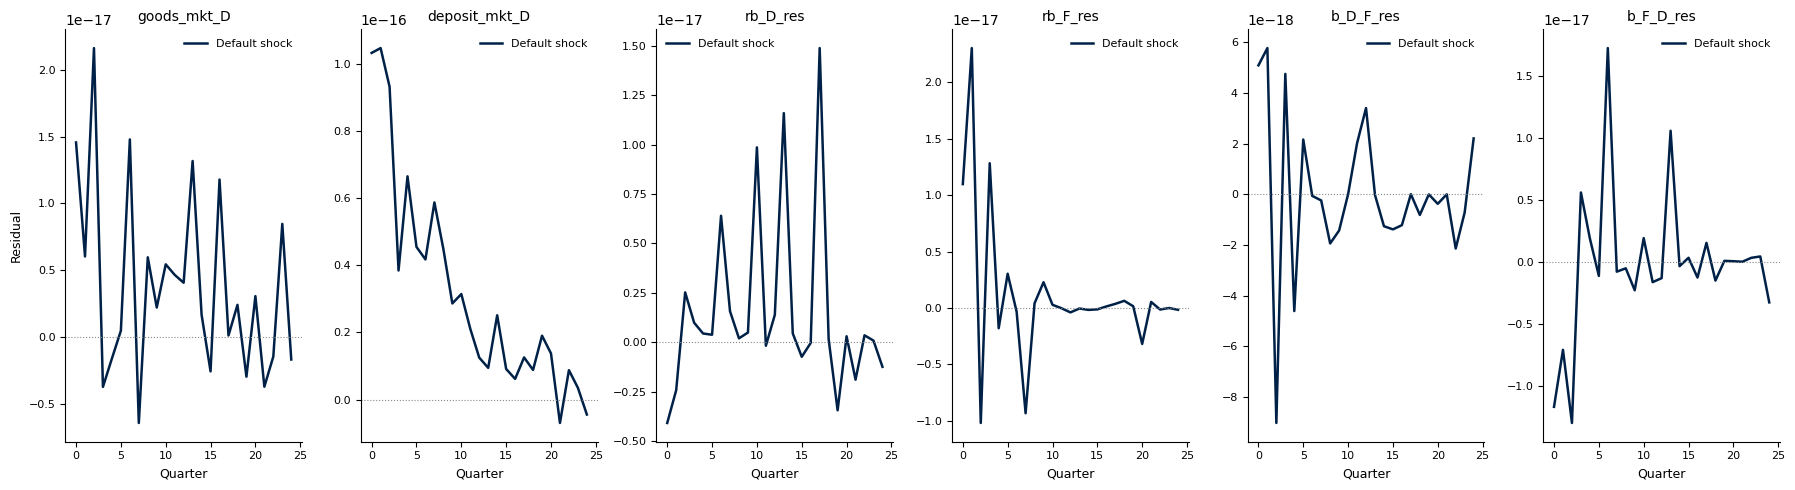

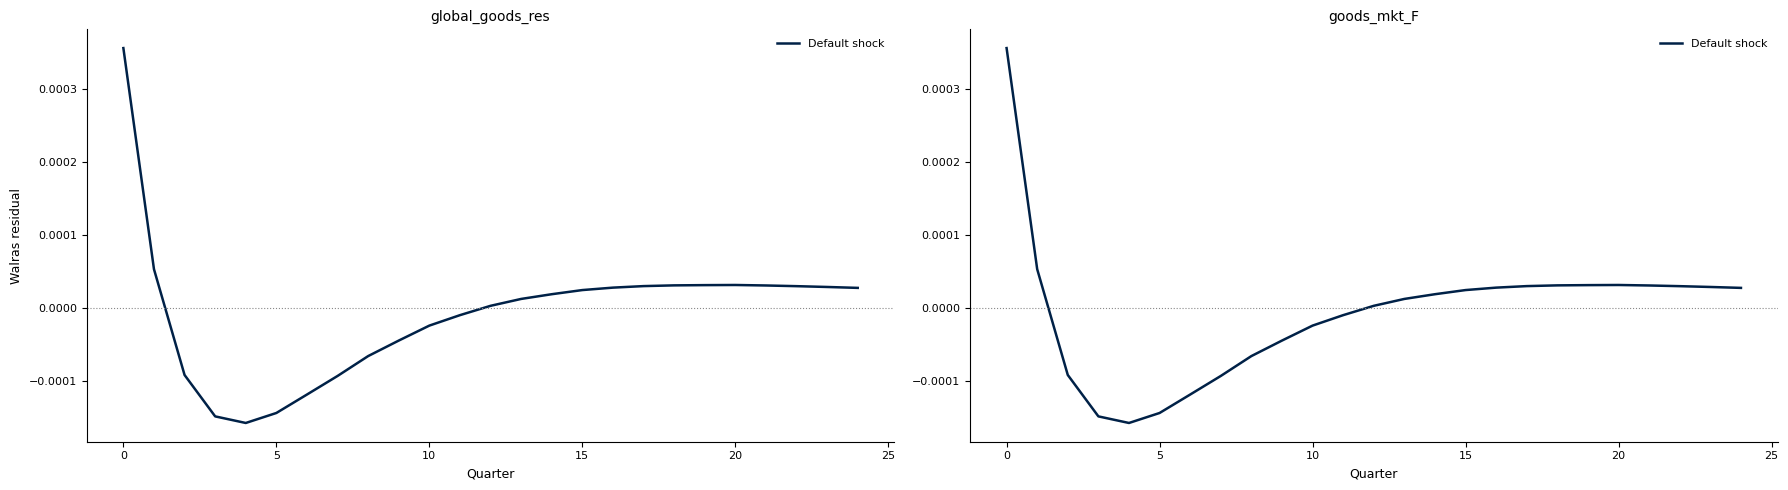

In [23]:
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_Z_D], labels=['TFP shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['goods_mkt_D', 'deposit_mkt_D', 'rb_D_res', 'rb_F_res',
                     'b_D_F_res', 'b_F_D_res'],
          ylabel='Residual')
show_irfs([irfs_def_D], labels=['Default shock'],
          variables=['global_goods_res', 'goods_mkt_F'],
          ylabel='Walras residual') 


In [ ]:
# ── Conference slide figures: 1pp Greek sovereign default shock ───────────────
# delta_b_D=0.036 (7yr duration), delta_b_F=0.038 (6.5yr duration)
# EBA bilateral sovereign calibration; phi_lamb=0.03 (Bohn_ann=0.12)
#
# Produces two figures saved to ../docs/figures/:
#   slide_default_shock_main.pdf   — 4-panel main result (spread, nw, output, contagion)
#   slide_default_shock_balance.pdf — 2-panel balance sheet amplification detail
#
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

_OUT_DIR = '../docs/figures'
os.makedirs(_OUT_DIR, exist_ok=True)

# ── Style ─────────────────────────────────────────────────────────────────────
BLUE    = '#002147'   # Oxford blue = D (Greece)
RED     = '#8C1515'   # Cardinal red = F (Germany)
GREY    = '#888888'

plt.rcParams.update({
    'font.family':    'serif',
    'font.size':      13,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize':11,
    'ytick.labelsize':11,
    'legend.fontsize':11,
    'figure.dpi':    150,
})

_T_plot = 24   # 6 years
_t      = np.arange(_T_plot)

def _pct(key, irf=irfs_def_D):
    return irf[key][:_T_plot] * 100

def _bps(key, irf=irfs_def_D):
    return irf[key][:_T_plot] * 10000

def _panel(ax, data, label, color, ls='-', ylabel=None, title=None, zero=True):
    ax.plot(_t, data, color=color, lw=2.2, ls=ls, label=label)
    if zero:
        ax.axhline(0, color=GREY, lw=0.8, ls=':')
    ax.set_xlabel('Quarter', fontsize=11)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=13, pad=5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, _T_plot - 1)

# ─────────────────────────────────────────────────────────────────────────────
# Figure 1: Main 4-panel slide (2×2)
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(11, 7))
fig1.suptitle('Greek Sovereign Default Shock  (1 pp, ρ=0.8)', fontsize=14, y=1.01)

ax = axes[0, 0]
_panel(ax, _bps('spread_rb'), 'Sovereign spread (D)', BLUE,
       ylabel='Basis points', title='Sovereign Spread (Greece)')

ax = axes[0, 1]
_panel(ax, _pct('n_inter_D'), 'Greek banks (D)',  BLUE, ylabel='% of SS', title='Bank Net Worth')
_panel(ax, _pct('n_inter_F'), 'German banks (F)', RED,  ls='--')
axes[0, 1].legend(frameon=False)

ax = axes[1, 0]
_panel(ax, _pct('Y_D'), 'Greece (D)', BLUE, ylabel='% deviation', title='Output')
_panel(ax, _pct('Y_F'), 'Germany (F)', RED, ls='--')
axes[1, 0].legend(frameon=False)

ax = axes[1, 1]
_panel(ax, _pct('q_b_D'), 'Greek bond price (D)',  BLUE, ylabel='% deviation', title='Bond Prices')
_panel(ax, _pct('q_b_F'), 'German bond price (F)', RED,  ls='--')
axes[1, 1].legend(frameon=False)

fig1.tight_layout()
_p1 = f'{_OUT_DIR}/slide_default_shock_main.pdf'
fig1.savefig(_p1, bbox_inches='tight')
print(f'Saved → {_p1}')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Figure 2: Balance sheet detail (1×3) — mechanism slide
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4))
fig2.suptitle('Balance Sheet Amplification  (Greek banks)', fontsize=14, y=1.02)

ax = axes2[0]
_panel(ax, _pct('n_inter_D'), 'Greek banks', BLUE,
       ylabel='% of SS net worth', title='Net Worth (D)')
_panel(ax, _pct('n_inter_F'), 'German banks', RED, ls='--')
axes2[0].legend(frameon=False)

ax = axes2[1]
_panel(ax, _pct('b_D_D'), 'Greek sov. (domestic)',  BLUE,
       ylabel='% of SS', title='Bond Holdings (D banks)')
_panel(ax, _pct('b_F_D'), 'German sov. (cross-border)', RED, ls='--')
axes2[1].legend(frameon=False)

ax = axes2[2]
_panel(ax, _pct('b_D_F'), 'Greek sov. (held by F)', BLUE,
       ylabel='% of SS', title='Cross-border Holdings')
_panel(ax, _pct('b_gov_D'), 'Greek debt stock', RED, ls='--')
axes2[2].legend(frameon=False)

fig2.tight_layout()
_p2 = f'{_OUT_DIR}/slide_default_shock_balance.pdf'
fig2.savefig(_p2, bbox_inches='tight')
print(f'Saved → {_p2}')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Print key numbers for slide annotations
# ─────────────────────────────────────────────────────────────────────────────
_db_D = float(ss['delta_b_D']); _db_F = float(ss['delta_b_F'])
_dur_D = (1-_db_D)/_db_D; _dur_F = (1-_db_F)/_db_F
print(f"\nDuration calibration:")
print(f"  delta_b_D={_db_D:.3f} → modified duration {_dur_D:.1f}Q = {_dur_D/4:.1f}yr  (target: ~7yr)")
print(f"  delta_b_F={_db_F:.3f} → modified duration {_dur_F:.1f}Q = {_dur_F/4:.1f}yr  (target: ~6.5yr)")
print(f"\nKey impact responses (t=0, 1pp default shock):")
print(f"  spread_rb[0]   = {irfs_def_D['spread_rb'][0]*1e4:+.1f} bps")
print(f"  n_inter_D[0]   = {irfs_def_D['n_inter_D'][0]*100:+.2f}%  (Greek bank net worth)")
print(f"  n_inter_F[0]   = {irfs_def_D['n_inter_F'][0]*100:+.2f}%  (German bank net worth)")
print(f"  q_b_D[0]       = {irfs_def_D['q_b_D'][0]*100:+.2f}%  (Greek bond price)")
print(f"  q_b_F[0]       = {irfs_def_D['q_b_F'][0]*100:+.2f}%  (German bond price — contagion)")
print(f"  Y_D[0]         = {irfs_def_D['Y_D'][0]*100:+.2f}%  (Greek output)")
print(f"  Y_F[0]         = {irfs_def_D['Y_F'][0]*100:+.2f}%  (German output)")
print(f"\nContagion ratio: n_inter_F[0]/n_inter_D[0] = {irfs_def_D['n_inter_F'][0]/irfs_def_D['n_inter_D'][0]:.3f}")
print(f"  (EBA share D_banks_hold_F / F_banks_hold_D = {0.0018/0.2447:.3f})")


In [ ]:
# ── def_scale diagnostic sweep ────────────────────────────────────────────────
# Scenarios: 0 = exogenous only, 1 = moderate (0.05), 2 = strong (0.10)
# phi_lamb = 0.03 → annual Bohn coefficient = phi_lamb * 4 = 0.12 (EA periphery range)
#
# def_scale → endogenous spread-debt slope ≈ def_scale × 430 bps per pp annual B/Y
#   scale=0.00 → 0 bps/pp   (exogenous sovereign risk only)
#   scale=0.05 → ~22 bps/pp (pre-crisis periphery order of magnitude)
#   scale=0.10 → ~43 bps/pp (crisis-regime calibration)
#
# HARD LIMIT with phi_lamb=0.03: def_scale < 0.13 (bifurcation; spectral radius > 1)
# With phi_lamb=0.40 the limit was 0.30 — weaker fiscal rule shrinks safe range.
#
# n_inter_D impact sign: at def_scale>0 the GK Bellman is forward-looking — higher
# future default risk raises required bond yields, which can increase bank franchise
# value on impact. This flips n_inter_D[0] positive for sc=0.05-0.10. Subsequent
# periods correctly show the net-worth deterioration as debt accumulates.

import copy, numpy as np

_scenarios = {
    'Scenario 0 (exogenous,   0.00)': 0.00,
    'Scenario 1 (moderate,    0.05)': 0.05,
    'Scenario 2 (strong,      0.10)': 0.10,
}

_T_diag  = 100
_rho     = 0.8
_dDef    = 0.01 * _rho ** np.arange(_T_diag)
_zeros   = np.zeros(_T_diag)

# Acceptance criteria (1pp default shock to D, ρ=0.8):
_SPEC_RAD_MAX      = 0.99     # < 1; near-unit-root debt dynamics are expected
_RANGE_SPREAD_BPS  = (0,  600)   # spread[0] bps — can be small with endogenous channel
_RANGE_NW_D_T5_PCT = (-40, 20)   # n_inter_D[5] pct — allow forward-looking positive impact
_RANGE_BGOV_PEAK   = (0.0, 15.0) # b_gov_D peak % of SS

print("=" * 80)
print("def_scale diagnostic sweep  (phi_lamb=0.03, Bohn_ann=0.12)")
print("Bifurcation at def_scale ≈ 0.13 with phi_lamb=0.03")
print("=" * 80)

_all_pass = True
for label, sc in _scenarios.items():
    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")

    # ── 1. SS exists ──────────────────────────────────────────────────────────
    ss_diag = copy.deepcopy(ss_final)
    ss_diag.toplevel['def_scale_D'] = sc

    goods_res = max(abs(float(ss_diag['goods_mkt_D'])),
                    abs(float(ss_diag['goods_mkt_F'])))
    ss_ok = goods_res < 1e-6
    print(f"  [SS]    goods residual max = {goods_res:.2e}  {'✓' if ss_ok else '✗ FAIL'}")
    if not ss_ok:
        _all_pass = False
        continue

    # ── 2. Jacobian + spectral radius ─────────────────────────────────────────
    try:
        G_diag = ha_full.solve_jacobian(
            ss_diag, unknowns=unknowns_tp, targets=targets_tp,
            inputs=['Z_D', 'shock_def_D', 'Z_F', 'shock_def_F'], T=_T_diag,
        )
    except Exception as e:
        print(f"  [JAC]   FAILED: {e}")
        _all_pass = False
        continue

    irf = G_diag.apply({'shock_def_D': _dDef, 'Z_D': _zeros,
                         'Z_F': _zeros, 'shock_def_F': _zeros})

    # Spectral radius: geometric decay rate of n_inter_D from T/4 to T/2
    _nw  = np.abs(irf['n_inter_D'])
    _t1, _t2 = _T_diag // 4, _T_diag // 2
    _dec = _nw[_t2] / _nw[_t1] if _nw[_t1] > 1e-12 else 0.0
    _rho_est = _dec ** (1.0 / (_t2 - _t1))
    spec_ok  = _rho_est < _SPEC_RAD_MAX
    print(f"  [JAC]   spectral radius ≈ {_rho_est:.4f}  (< {_SPEC_RAD_MAX})  {'✓' if spec_ok else '✗ FAIL'}")
    if not spec_ok:
        _all_pass = False

    # ── 3. IRF smoothness: sign flips in n_inter_D before t=20 ────────────────
    _sign_flips = int(np.sum(np.diff(np.sign(irf['n_inter_D'][:20])) != 0))
    smooth_ok   = _sign_flips <= 2   # allow ≤2 turning points (GK forward-looking)
    print(f"  [IRF]   n_inter_D sign flips (t<20) = {_sign_flips}  {'✓' if smooth_ok else '✗ NOT SMOOTH'}")
    if not smooth_ok:
        _all_pass = False

    # ── 4. Range checks ───────────────────────────────────────────────────────
    _b_ss   = float(ss_diag['b_gov_D'])
    _bgpk   = float(np.max(np.abs(irf['b_gov_D']))) / _b_ss * 100
    _spr0   = irf['spread_rb'][0] * 10000 if 'spread_rb' in irf else float('nan')
    _nw5    = irf['n_inter_D'][5] * 100   # t=5 for forward-looking stabilisation

    bgov_ok = _RANGE_BGOV_PEAK[0]  <= _bgpk <= _RANGE_BGOV_PEAK[1]
    spr_ok  = _RANGE_SPREAD_BPS[0] <= _spr0 <= _RANGE_SPREAD_BPS[1]
    nw_ok   = _RANGE_NW_D_T5_PCT[0]<= _nw5  <= _RANGE_NW_D_T5_PCT[1]

    print(f"  [RANGE] b_gov_D peak  = {_bgpk:+.2f}%    [{_RANGE_BGOV_PEAK[0]}, {_RANGE_BGOV_PEAK[1]}]   {'✓' if bgov_ok else '✗'}")
    print(f"  [RANGE] spread[0]     = {_spr0:+.1f} bps [{_RANGE_SPREAD_BPS[0]}, {_RANGE_SPREAD_BPS[1]}]    {'✓' if spr_ok else '✗'}")
    print(f"  [RANGE] n_inter_D[5]  = {_nw5:+.2f}%    [{_RANGE_NW_D_T5_PCT[0]}, {_RANGE_NW_D_T5_PCT[1]}]  {'✓' if nw_ok else '✗'}")

    if not (bgov_ok and spr_ok and nw_ok):
        _all_pass = False

    # ── Calibration summary ───────────────────────────────────────────────────
    _ann_BY      = _b_ss / 4 * 100
    _bohn        = float(ss_diag['phi_lamb_D']) * 4
    _spr_slope   = sc * 430
    _nw0         = irf['n_inter_D'][0] * 100
    print(f"  [CAL]   ann B/Y={_ann_BY:.1f}%  Bohn_ann={_bohn:.3f}  spr-slope≈{_spr_slope:.0f} bps/pp")
    print(f"  [CAL]   n_inter_D[0]={_nw0:+.2f}%  n_inter_D[5]={_nw5:+.2f}%"
          + ("  (forward-looking GK franchise gain on impact)" if _nw0 > 0 else ""))

    ss_diag.toplevel['def_scale_D'] = 0.0

print(f"\n{'='*80}")
print(f"Overall: {'ALL PASS ✓' if _all_pass else 'SOME CHECKS FAILED ✗'}")
print(f"{'='*80}")
print(f"\nNote: def_scale=0.00 n_inter_D[0] < 0 (direct loss); "
      f"def_scale=0.05-0.10 n_inter_D[0] > 0 (GK Bellman: higher future yields")
print(f"raise franchise value on impact, then net worth decays as debt accumulates).")
